In [14]:
from astropy.table import Table
import redrock
from astropy.io import fits
import astropy.units as u

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from prospect.viewer import plotspectra
from redrock.templates import load_templates_from_header, eval_model

from desispec.io import read_spectra
from desispec.coaddition import coadd_cameras
from desispec.spectra import stack as specstack

In [2]:
# read in targ table and julia morph table
targs = Table.read('Magellan_2026B_ra345100_dec-8931_z0p05_Mr-15_priority.fits')
morph = Table.read('Dwarf_Mag_Irregulars.csv')

In [3]:
targs[:5]

TARGETID,RA,DEC,Z,ABSMAG01_SDSS_U,ABSMAG01_SDSS_G,ABSMAG01_SDSS_R,ABSMAG01_SDSS_Z,LOGMSTAR,SFR,HALPHA_EW,BGS_TARGET,Irr
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64
39627580038449192,2.122124969761184,-8.474668989823174,0.03793164077991966,-14.874427795410156,-15.924508094787598,-16.39629364013672,-16.67608642578125,8.365667343139648,9.038781718118116e-05,42.74867630004883,131074,-1
39627622036014144,5.8102585361138255,-6.770001602692444,0.01872175879778077,-14.938359260559082,-15.594433784484863,-15.908570289611816,-16.064807891845703,7.784867286682129,1.0312628528907908e-09,288.98876953125,131074,-1
39627634048500496,5.80122582921423,-6.372368380584375,0.041790771222192956,-13.945151329040527,-15.082871437072754,-15.523889541625977,-15.741202354431152,7.914829254150391,0.0009575361618772149,16.34628677368164,65545,-1
39627628042262736,5.98788551670245,-6.407500996384865,0.04251104529956576,-14.700377464294434,-15.814504623413086,-16.203479766845703,-16.381473541259766,8.106237411499023,1.3069629858364351e-05,19.88756561279297,131074,-1
39627634044309904,5.652799977699593,-6.3491469201057615,0.04173502758697374,-14.97079849243164,-16.096391677856445,-16.791757583618164,-17.231966018676758,8.67609977722168,1.4747641330359329e-08,2.6047635078430176,131074,-1


In [4]:
morph[:5]

targetid,Predicted_Label,Predicted_Type
int64,int64,str9
2389179178680322,0,Other
2389185012957184,0,Other
2389196757008387,0,Other
2389238049931266,0,Other
2389249882062849,0,Other


In [5]:
targs_dict= {}
for i in range(len(targs)):

    targs_dict[targs['TARGETID'][i]] = i
    

In [6]:
for i in range(len(morph)):

    idx = targs_dict[morph['targetid'][i]]
    targs['Irr'][idx] = morph['Predicted_Label'][i]

In [7]:
dIrrs = targs[targs['Irr'] == 1]

In [8]:
dIrrs[np.argsort(dIrrs['ABSMAG01_SDSS_R'])][2000:]

TARGETID,RA,DEC,Z,ABSMAG01_SDSS_U,ABSMAG01_SDSS_G,ABSMAG01_SDSS_R,ABSMAG01_SDSS_Z,LOGMSTAR,SFR,HALPHA_EW,BGS_TARGET,Irr
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64
39627688406683104,16.879130952550167,-4.024672570239263,0.019922688893003183,-15.659972190856934,-16.235366821289062,-16.295101165771484,-16.178409576416016,7.308162212371826,0.005706409458070993,980.491455078125,131074,1
39627427076375256,50.9725241392316,-15.065373933582068,0.04181446524071888,-15.312749862670898,-15.977911949157715,-16.29500389099121,-16.44221305847168,8.005548477172852,4.87612014694605e-05,26.748567581176758,131074,1
39627479895251344,51.92579924828273,-12.808615324215147,0.04125567368219484,-14.822015762329102,-15.816913604736328,-16.29487419128418,-16.57351303100586,8.30374813079834,2.306496105219935e-09,24.887081146240234,131074,1
39636288051088624,67.62719762909083,-12.185881234115062,0.03557675223867469,-15.170209884643555,-15.890783309936523,-16.29462242126465,-16.562360763549805,8.25439167022705,0.004818955902010202,27.684629440307617,131074,1
39627724284757800,357.33188830345847,-2.761131028976906,0.030363655218356565,-14.508901596069336,-15.726397514343262,-16.29458236694336,-16.55497169494629,8.14002799987793,3.7981776057627314e-10,6.463998317718506,131074,1
39627615811665984,352.19774405309215,-7.353077981139257,0.04621749335563048,-14.59863567352295,-15.835171699523926,-16.294198989868164,-16.483318328857422,8.254776000976562,0.0003378011751919985,13.224249839782715,131074,1
39627712393904560,8.510316341191565,-2.878125505131086,0.019663476339014878,-14.67309284210205,-15.859902381896973,-16.2935733795166,-16.456279754638672,7.969423294067383,4.2898321339635004e-08,59.10591506958008,131074,1
39627682324945752,13.98359232249937,-4.28568318807818,0.04500753565981726,-14.680811882019043,-15.771127700805664,-16.29336929321289,-16.629596710205078,8.398687362670898,0.002051037037745118,24.243511199951172,131074,1
39627736662155824,15.244829433644178,-2.0416654263288634,0.045674859120021435,-15.584479331970215,-16.14341163635254,-16.293319702148438,-16.3284854888916,8.055558204650879,0.016192778944969177,127.67827606201172,131074,1


In [24]:
print(np.max(dIrrs['RA'][dIrrs['RA'] < 90])*u.degree.to(u.hourangle))
print(np.min(dIrrs['RA'][dIrrs['RA'] > 90])*u.degree.to(u.hourangle))

# plt.hist((dIrrs['RA']*u.degree).to(u.hourangle))

5.054593520646287
23.007021858181815


In [26]:
print(np.min(dIrrs['DEC']))
print(np.max(dIrrs['DEC']))

-17.66933398053668
-2.000647996669846


In [9]:
targetid = 39627427076375256
healpix = 36287 # from target table

### try to get sepctra

In [10]:
test_spec = read_spectra('/global/cfs/cdirs/desi/spectro/redux/loa/healpix/main/bright/362/36287/spectra-main-bright-36287.fits.gz', targetids=[targetid])

INFO:spectra.py:469:read_spectra: iotime 10.513 sec to read spectra from:  spectra-main-bright-36287.fits.gz at 2026-04-24T14:11:38.066365


In [11]:
# plotspectra(test_spec, notebook=1)

In [12]:
# try to read model
hdu = fits.open('/global/cfs/cdirs/desi/spectro/redux/loa/healpix/main/bright/362/36287/rrmodel-main-bright-36287.fits')

In [13]:
templates = load_templates_from_header(hdu[0].header)

Reading templates from ['/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/code/redrock-templates/main/rrtemplate-GALAXY-None-v2.6.fits', '/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/code/redrock-templates/main/rrtemplate-QSO-LOZ-v1.0.fits', '/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/code/redrock-templates/main/rrtemplate-QSO-HIZ-v1.1.fits', '/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/code/redrock-templates/main/rrtemplate-STAR-A-v0.1.fits', '/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/code/redrock-templates/main/rrtemplate-STAR-B-v0.1.fits', '/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/code/redrock-templates/main/rrtemplate-STAR-CV-v0.1.fits', '/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/code/redrock-templates/main/rrtemplate-STAR-F-v0.1.fits', '/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/code/redrock-templates/main/rrtemp

In [14]:
hp_table = Table(hdu[1].data)

In [15]:
test_targ_idx = np.where(hp_table['TARGETID'] == targetid)[0][0]

In [16]:
b_wave = hdu[2].data
b_model = hdu[3].data[test_targ_idx]
r_wave = hdu[4].data
r_model = hdu[5].data[test_targ_idx]
z_wave = hdu[6].data
z_model = hdu[7].data[test_targ_idx]

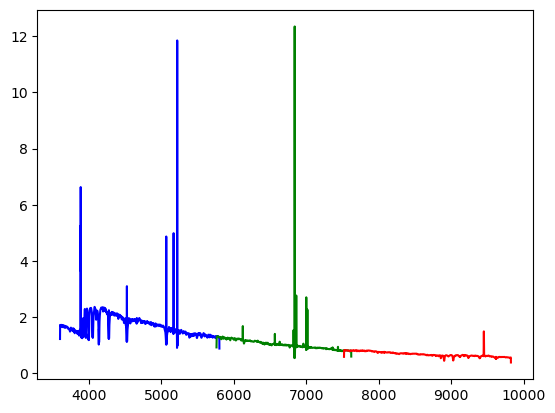

In [17]:
plt.plot(b_wave, b_model, color='b')
plt.plot(r_wave, r_model, color='g')
plt.plot(z_wave, z_model, color='r')

(6700.0, 7000.0)

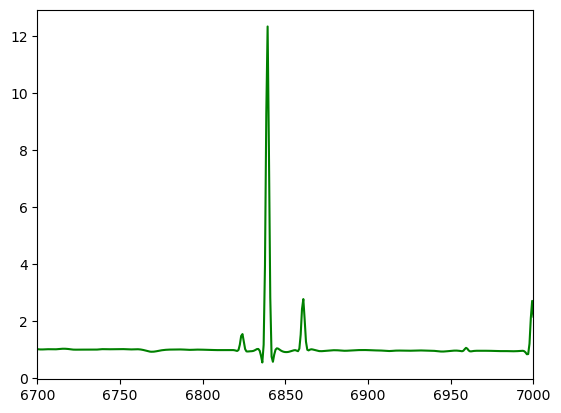

In [19]:
# zoom in on Ha
plt.plot(r_wave, r_model, color='g')
plt.xlim(6700,7000)

In [21]:
spec_hdu = fits.PrimaryHDU()

In [22]:
spec_hdu1= fits.ImageHDU(b_wave)
spec_hdu1.header['EXTNAME'] = 'B_WAVELENGTH'
spec_hdu1.header['BUNIT'] = 'Angstrom'


In [23]:
spec_hdu2= fits.ImageHDU(test_spec.flux['b'])
spec_hdu2.header['EXTNAME'] = 'B_FLUX'
spec_hdu2.header['BUNIT'] = '10**-17 erg/(s cm2 Angstrom)'

spec_hdu3= fits.ImageHDU(b_model)
spec_hdu3.header['EXTNAME'] = 'B_MODEL'
spec_hdu3.header['BUNIT'] = '10**-17 erg/(s cm2 Angstrom)'

In [24]:
spec_hdu4= fits.ImageHDU(r_wave)
spec_hdu4.header['EXTNAME'] = 'R_WAVELENGTH'
spec_hdu4.header['BUNIT'] = 'Angstrom'

spec_hdu5= fits.ImageHDU(test_spec.flux['r'])
spec_hdu5.header['EXTNAME'] = 'R_FLUX'
spec_hdu5.header['BUNIT'] = '10**-17 erg/(s cm2 Angstrom)'

spec_hdu6= fits.ImageHDU(r_model)
spec_hdu6.header['EXTNAME'] = 'R_MODEL'
spec_hdu6.header['BUNIT'] = '10**-17 erg/(s cm2 Angstrom)'


spec_hdu7= fits.ImageHDU(z_wave)
spec_hdu7.header['EXTNAME'] = 'Z_WAVELENGTH'
spec_hdu7.header['BUNIT'] = 'Angstrom'

spec_hdu8= fits.ImageHDU(test_spec.flux['z'])
spec_hdu8.header['EXTNAME'] = 'Z_FLUX'
spec_hdu8.header['BUNIT'] = '10**-17 erg/(s cm2 Angstrom)'

spec_hdu9= fits.ImageHDU(z_model)
spec_hdu9.header['EXTNAME'] = 'Z_MODEL'
spec_hdu9.header['BUNIT'] = '10**-17 erg/(s cm2 Angstrom)'

In [25]:
spec_hdu.header['TARGETID'] = str(targetid)
spec_hdu.header['SURVEY'] = 'main'
spec_hdu.header['PROGRAM'] = 'bright'

In [26]:
hdul = fits.HDUList([spec_hdu, spec_hdu1, spec_hdu2, spec_hdu3, spec_hdu4, spec_hdu5, spec_hdu6, spec_hdu7, spec_hdu8, spec_hdu9])

In [28]:
hdul.writeto(str(targetid) + '_redrock_spec_model.fits', overwrite=True)